In [ ]:
pip install pymongo pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 11.0 MB/s eta 0:00:00


In [ ]:
pip install pymongo certifi

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf # Data from Yahoo Finance
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from pymongo import MongoClient, UpdateOne
import certifi

# ETL

In [ ]:
def ETL():
    sp500 = yf.Ticker("^GSPC").history(period="20y")
    vix = yf.Ticker("^VIX").history(period="20y")
    move = yf.Ticker("^MOVE").history(period="20y")
    vix3m = yf.Ticker("^VIX3M").history(period="20y")
    dxy = yf.Ticker("DX-Y.NYB").history(period="20y")
    gold = yf.Ticker("GC=F").history(period="20y")
    oil = yf.Ticker("CL=F").history(period="20y")
    hvyg = yf.Ticker("HYG").history(period="20y")
    ivig = yf.Ticker("LQD").history(period="20y")

    sp500 = sp500.drop(columns=["Dividends","Stock Splits"])
    vix = vix.drop(columns=["Dividends","Stock Splits","Volume"])
    move = move.drop(columns=["Dividends","Stock Splits","Volume"])
    vix3m = vix3m.drop(columns=["Dividends","Stock Splits","Volume"])
    dxy = dxy.drop(columns=["Dividends","Stock Splits","Volume"])
    gold = gold.drop(columns=["Dividends","Stock Splits","Volume"])
    oil = oil.drop(columns=["Dividends","Stock Splits","Volume"])
    hvyg = hvyg.drop(columns=["Dividends","Stock Splits","Volume"])
    ivig = ivig.drop(columns=["Dividends","Stock Splits","Volume"])

    def rename_asset(df,suffix):
        return df.rename(columns={
            "Open":f"Open_{suffix}",
            "High":f"High_{suffix}",
            "Low":f"Low_{suffix}",
            "Close":f"Close_{suffix}",
            "Volume":f"Volume_{suffix}"
        })

    sp500 = rename_asset(sp500,"SP500")
    vix = rename_asset(vix,"VIX")
    move = rename_asset(move,"MOVE")
    vix3m = rename_asset(vix3m,"VIX3M")
    dxy = rename_asset(dxy,"DXY")
    gold = rename_asset(gold,"GOLD")
    oil = rename_asset(oil,"OIL")
    hvyg = rename_asset(hvyg,"HYG")
    ivig = rename_asset(ivig,"LQD")

    for df in [sp500,vix,move,vix3m,dxy,gold,oil,hvyg,ivig]:
        df.index = df.index.tz_localize(None)

    dataset = pd.concat([sp500,vix,move,vix3m,dxy,gold,oil,hvyg,ivig],axis=1).sort_index()

    dataset["Return_SPX"]  = dataset["Close_SP500"].pct_change(fill_method=None)
    dataset["Return_VIX"]  = dataset["Close_VIX"].pct_change(fill_method=None)
    dataset["Return_MOVE"] = dataset["Close_MOVE"].pct_change(fill_method=None)
    dataset["Return_VIX3M"]= dataset["Close_VIX3M"].pct_change(fill_method=None)
    dataset["RV_5d"] = dataset["Return_SPX"].rolling(5).std()*np.sqrt(252)
    dataset["RV_10d"] = dataset["Return_SPX"].rolling(10).std()*np.sqrt(252)
    dataset["RV_21d"] = dataset["Return_SPX"].rolling(21).std()*np.sqrt(252)
    dataset["VIX_Vol_5d"] = dataset["Return_VIX"].rolling(5).std()
    dataset["VIX_Vol_10d"] = dataset["Return_VIX"].rolling(10).std()
    dataset["VIX_Vol_21d"] = dataset["Return_VIX"].rolling(21).std()
    dataset["VIX_Lag1"] = dataset["Close_VIX"].shift(1)
    dataset["VIX_Lag2"] = dataset["Close_VIX"].shift(2)
    dataset["VIX_Lag5"] = dataset["Close_VIX"].shift(5)
    dataset["VIX_MA_5"] = dataset["Close_VIX"].rolling(5).mean()
    dataset["VIX_MA_10"] = dataset["Close_VIX"].rolling(10).mean()
    dataset["VIX_MA_20"] = dataset["Close_VIX"].rolling(20).mean()
    dataset["VIX_STD_5"] = dataset["Close_VIX"].rolling(5).std()
    dataset["VIX_STD_10"] = dataset["Close_VIX"].rolling(10).std()
    dataset["VIX_Percentile"] = dataset["Close_VIX"].rank(pct=True)
    dataset["SPX_Volume_Norm"] = dataset["Volume_SP500"]/dataset["Volume_SP500"].rolling(252).mean()
    dataset["VIX3M_Spread"] = dataset["Close_VIX"] - dataset["Close_VIX3M"]
    dataset["VIX_Contango"] = dataset["Close_VIX3M"]/dataset["Close_VIX"] - 1
    dataset["SPX_Gap"] = (dataset["Open_SP500"] - dataset["Close_SP500"].shift(1))/dataset["Close_SP500"].shift(1)
    dataset["VIX_Gap"] = (dataset["Open_VIX"] - dataset["Close_VIX"].shift(1))/dataset["Close_VIX"].shift(1)
    dataset["Drawdown"] = dataset["Close_SP500"]/dataset["Close_SP500"].cummax() -1
    dataset["Momentum_1M"] = dataset["Close_SP500"]/dataset["Close_SP500"].shift(21)-1
    dataset["Momentum_3M"] = dataset["Close_SP500"]/dataset["Close_SP500"].shift(63)-1
    dataset["Momentum_6M"] = dataset["Close_SP500"]/dataset["Close_SP500"].shift(126)-1
    dataset["VIX_Zscore"] = (dataset["Close_VIX"]-dataset["VIX_MA_20"])/dataset["VIX_STD_10"]
    dataset["VIX_MeanRev"] = dataset["Close_VIX"] - dataset["VIX_MA_10"]
    dataset["IV_RV_Ratio"] = dataset["Close_VIX"]/dataset["RV_21d"]
    dataset["VIX_RV_Spread"] = dataset["Close_VIX"] - dataset["RV_21d"]
    dataset["VIX_Trend"] = dataset["Close_VIX"].ewm(span=21,adjust=False).mean() - dataset["Close_VIX"].ewm(span=63,adjust=False).mean()
    dataset["VIX_MOVE_Ratio"] = dataset["Close_VIX"]/dataset["Close_MOVE"]
    dataset["SPX_VIX_Corr_21d"] = dataset["Return_SPX"].rolling(21).corr(dataset["Return_VIX"])
    dataset["RV_21d_Sq"] = dataset["RV_21d"]**2
    dataset["VIX_Zscore_Sq"] = dataset["VIX_Zscore"]**2
    dataset["Intraday_VIX_Return"] = (dataset["Close_VIX"]-dataset["Open_VIX"])/dataset["Open_VIX"]
    q_up = dataset["Intraday_VIX_Return"].quantile(0.66)
    q_down = dataset["Intraday_VIX_Return"].quantile(0.33)
    dataset["Intraday_VIX_Move"] = np.where(dataset["Intraday_VIX_Return"]>=q_up,1,np.where(dataset["Intraday_VIX_Return"]<=q_down,2,0))

    feature_cols = [
        "Open_SP500","Open_VIX","Open_MOVE",
        "Drawdown",
        "Momentum_1M","Momentum_3M","Momentum_6M",
        "RV_5d","RV_10d","RV_21d",
        "VIX_Vol_5d","VIX_Vol_10d","VIX_Vol_21d",
        "VIX_Lag1","VIX_Lag2","VIX_Lag5",
        "VIX_MA_5","VIX_MA_10","VIX_MA_20",
        "VIX_STD_5","VIX_STD_10","VIX_Percentile",
        "SPX_Volume_Norm",
        "VIX3M_Spread","VIX_Contango",
        "SPX_Gap","VIX_Gap",
        "VIX_Zscore","VIX_Zscore_Sq","VIX_MeanRev",
        "IV_RV_Ratio","VIX_RV_Spread","VIX_Trend",
        "VIX_MOVE_Ratio","SPX_VIX_Corr_21d","RV_21d_Sq",
        "Close_DXY","Close_GOLD","Close_OIL",
        "Close_HYG","Close_LQD"
    ]

    dataset_final = dataset[feature_cols + ["Intraday_VIX_Move"]].dropna()
    return dataset_final,dataset,q_up,q_down

In [ ]:
data, dataset, q_up, q_down =ETL()
data.head()

,Open_SP500,Open_VIX,Open_MOVE,Drawdown,Momentum_1M,Momentum_3M,Momentum_6M,RV_5d,RV_10d,RV_21d,...,VIX_Trend,VIX_MOVE_Ratio,SPX_VIX_Corr_21d,RV_21d_Sq,Close_DXY,Close_GOLD,Close_OIL,Close_HYG,Close_LQD,Intraday_VIX_Move
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-02,1467.969971,22.580000,148.699997,-0.075386,-0.022942,-0.064314,-0.050962,0.123234,0.156126,0.178649,...,-0.369749,0.155817,-0.866893,0.031916,75.970001,857.000000,99.620003,32.466614,52.854874,1
2008-01-03,1447.550049,23.110001,145.600006,-0.075386,-0.017155,-0.060035,-0.051291,0.120248,0.152337,0.177800,...,-0.320274,0.154464,-0.861788,0.031613,75.889999,866.400024,99.180000,32.404613,52.680527,0
2008-01-04,1444.010010,23.500000,138.100006,-0.098086,-0.034974,-0.085044,-0.077631,0.171577,0.194630,0.195263,...,-0.189286,0.173353,-0.860007,0.038128,75.790001,863.099976,97.910004,32.368713,53.113956,1
2008-01-07,1414.069946,24.620001,130.899994,-0.095179,-0.046350,-0.090788,-0.075510,0.178422,0.192943,0.186484,...,-0.082339,0.181742,-0.854692,0.034776,76.169998,859.599976,95.089996,32.176193,53.049198,2
2008-01-08,1415.709961,23.270000,124.000000,-0.111785,-0.077720,-0.104594,-0.079418,0.189942,0.172018,0.183463,...,0.109923,0.205081,-0.849428,0.033659,76.110001,878.000000,96.330002,31.990236,52.949585,1


In [ ]:
dataset["Intraday_VIX_Move"]. value_counts()

,count
Intraday_VIX_Move,
1,1711
0,1667
2,1661


In [ ]:
print(q_up*100,q_down*100)

0.8152332130802601 -3.335078707237508


In [ ]:
uri = "blured"
client = MongoClient(uri, tls=True, tlsCAFile=certifi.where())

db = client["DB_VIX"]
collection = db["vix_data"]

data_mongo = data.copy()
data_mongo["_id"] = data_mongo.index.astype(str)  # use datetime as _id

records = data_mongo.to_dict("records")

operations = [
    UpdateOne(
        {"_id": r["_id"]},
        {"$set": r},  # will insert new fields if they exist
        upsert=True
    )
    for r in records
]

if operations:
    result = collection.bulk_write(operations)
    print(f"Inserted or updated records: {result.upserted_count + result.modified_count}")
else:
    print("No new data to insert/update")

Inserted or updated records: 3957


# Model

### Walk-forward expanding window

Split 1
Initial training only
--------------------------------------------------
Split 2
Train size: 100 / Test size: 1
Train From: 2021-08-12 to 2022-01-05
Test Date: 2022-01-06
--------------------------------------------------
Split 3
Train size: 100 / Test size: 1
Train From: 2021-08-13 to 2022-01-06
Test Date: 2022-01-07
--------------------------------------------------
Split 4
Train size: 100 / Test size: 1
Train From: 2021-08-16 to 2022-01-07
Test Date: 2022-01-10
--------------------------------------------------
Split 5
Train size: 100 / Test size: 1
Train From: 2021-08-17 to 2022-01-10
Test Date: 2022-01-11
--------------------------------------------------


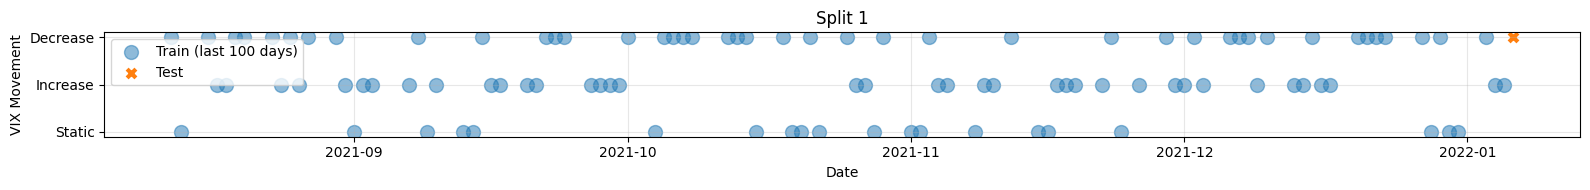

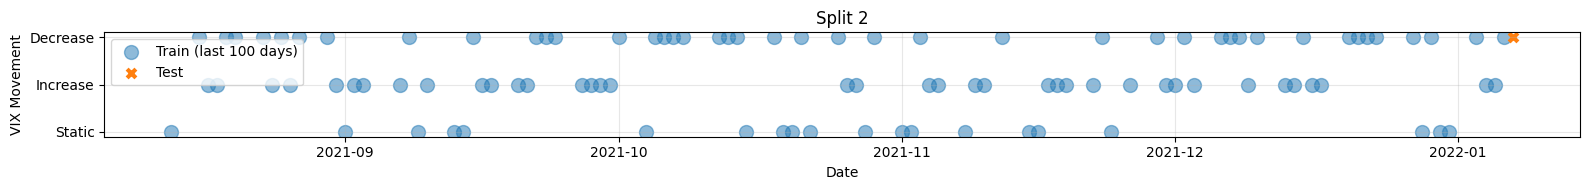

In [ ]:
def clean_features(X):
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.ffill()          # forward fill
    X = X.fillna(0)
    X = X.astype(np.float64)
    return X


def walk_forward_expanding(data, initial_years=15, daily_window=100):

    # Split the features of the model from the target
    X = data.drop(columns=["Intraday_VIX_Move"]).copy()
    y = data["Intraday_VIX_Move"].copy()

    all_splits = []

    initial_window = initial_years * 252  # approx trading days per year

    if initial_window > len(data):
        raise ValueError("The dataset is smaller than the initial years.")

    # INITIAL TRAINING
    X_train_init = X.iloc[:initial_window].copy()
    y_train_init = y.iloc[:initial_window].copy()

    # Clean BEFORE scaling
    X_train_init = clean_features(X_train_init)

    scaler_init = StandardScaler()
    X_train_init_scaled = pd.DataFrame(
        scaler_init.fit_transform(X_train_init),
        index=X_train_init.index,
        columns=X_train_init.columns
    )

    all_splits.append((X_train_init_scaled, None, y_train_init, None))

    # DAILY WALK-FORWARD
    for i in range(initial_window, len(data)):

        X_train = X.iloc[i - daily_window:i].copy()
        y_train = y.iloc[i - daily_window:i].copy()

        X_test = X.iloc[i:i + 1].copy()
        y_test = y.iloc[i:i + 1].copy()

        # 🔹 Clean before scaling
        X_train = clean_features(X_train)

        scaler = StandardScaler()
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train),
            index=X_train.index,
            columns=X_train.columns
        )

        # 🔹 Clean test using same logic
        X_test = X_test.replace([np.inf, -np.inf], np.nan)
        X_test = X_test.ffill().fillna(0).astype(np.float64)

        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test),
            index=X_test.index,
            columns=X_test.columns
        )

        all_splits.append((X_train_scaled, X_test_scaled, y_train, y_test))

    return all_splits

splits = walk_forward_expanding(data, initial_years=15, daily_window=100)

for i, (X_train, X_test, y_train, y_test) in enumerate(splits[:5]):
    print(f"Split {i+1}")
    if X_test is None:
        print("Initial training only")
    else:
        print("Train size:", len(X_train), "/ Test size:", len(X_test))
        print("Train From:", X_train.index[0].date(), "to", X_train.index[-1].date())
        print("Test Date:", X_test.index[0].date())
    print("-" * 50)

last_n_days = 100

for i, (X_train, X_test, Y_train, Y_test) in enumerate(splits[1:3]):

    if X_test is None or Y_test is None:
        continue  # skip initial split

    Y_train_last = Y_train.iloc[-last_n_days:]
    Y_test_day = Y_test

    plt.figure(figsize=(16, 2))
    plt.scatter(Y_train_last.index, Y_train_last,
                label='Train (last 100 days)', s=100, alpha=0.5)
    plt.scatter(Y_test_day.index, Y_test_day,
                label='Test', s=40, marker='x', linewidths=3)

    plt.xlabel("Date")
    plt.ylabel("VIX Movement")
    plt.yticks([0, 1, 2], ['Static', 'Increase', 'Decrease'])
    plt.title(f"Split {i+1}")
    plt.legend(loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()